In [1]:
import torch
import os
import json
import numpy as np
import pandas as pd
import random
import statistics
from itertools import groupby
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib
from plotting_style import *
from risk_control_utils import rc_main

# Parameters
Specify all parameters for this notebook. 

In [3]:
u_prop, a_prop = 50, 50 # the % of total observations of each type. do 5/95, 10/90, 25/75, 50/50
display_legends = False # whether to include legends on plots (all or none)
max_eps = 0.1 # the maximum epsilon-value to plot. For the paper, this is between 0.1 and 0.5. 
n_trials = 50 # the number of risk-control iterations to run.

# Define Variables
These should not need to be modified to reproduce the results from the "Safe In-Context Learning" paper.

In [5]:
# Define base data folder to read from (and associated params for finding the right data files)
# different for different splits, e.g. 10_90_mix, 5_95_mix
mixed_filename = str(u_prop) + 'u_' + str(a_prop) + 'a_mix'
precomputed_path = './rc-precomputed/calm/'
precomputed_mixed_path = precomputed_path + mixed_filename + '/'

In [6]:
# Define plotting params
c_color, i_color, z_color = 'tab:blue', 'tab:orange', 'tab:green'
first_exit=12 # for risk control, this sets the earliest layer at which we are allowed to exit
plot_directory = './calm_plots/'

In [7]:
# Define lambdas and epsilons
# NOTE: If running with loss_01_conversion=max_0, cannot have epsilon < 0!
stepsize = 0.01
eps_grid = np.arange(0.0, max_eps + stepsize, stepsize)
lambdas = np.arange(0.0, 1.0 + stepsize, stepsize)[::-1]

In [8]:
# Define loss and risk-control parameters
relative_labels = 'zeroshot_full_model' # zeroshot_full_model or full_model; the predictions over which to compute a relative loss
ground_truth_type = 'true_label' # the ground-truth for computing loss; true_label or zeroshot_full_model
delta=0.1

# Pre-Compute Risk Control Results
This makes plotting much more efficient. 

In [10]:
def get_mix(answerable, unanswerable, a_exits, u_exits, a_prop):
    # A: shape (N, M1), B: shape (N, M2)
    N, M1 = answerable.shape
    _, M2 = unanswerable.shape
    n_total = min(answerable.shape[1], unanswerable.shape[1])
    
    # number of columns to sample from each
    k_A = int(round(n_total * a_prop))
    k_U = n_total - k_A  
    
    # randomly choose columns
    cols_A = np.random.choice(M1, k_A, replace=False)
    cols_U = np.random.choice(M2, k_U, replace=False)
    
    # concatenate losses along columns
    losses = np.concatenate([answerable[:, cols_A], unanswerable[:, cols_U]], axis=1)
    # concatenate exits along columns
    exits = np.concatenate([a_exits[:, cols_A], u_exits[:, cols_U]], axis=1)
    return losses, exits

In [11]:
def load_all_data(precomputed_path):
    # Read in the loss and exit matrices for both answerable and un-answerable questions
    a_losses = np.load(precomputed_path + "a_losses.npy")
    a_exits = np.load(precomputed_path + "a_exits.npy")
    u_losses = np.load(precomputed_path + "u_losses.npy")
    u_exits = np.load(precomputed_path + "u_exits.npy")
    # Read in zero-shot losses and average exit (final layer)
    za_losses = np.load(precomputed_path + "za_losses.npy")
    zu_losses = np.load(precomputed_path + "zu_losses.npy")
    # Read in default to zero-shot
    a_defaulted_losses = np.load(precomputed_path + "a_defaulted_losses.npy")
    a_defaulted_exits = np.load(precomputed_path + "a_defaulted_exits.npy")
    u_defaulted_losses = np.load(precomputed_path + "u_defaulted_losses.npy")
    u_defaulted_exits = np.load(precomputed_path + "u_defaulted_exits.npy")
    return a_losses, a_exits, u_losses, u_exits, za_losses, zu_losses, a_defaulted_losses, a_defaulted_exits, u_defaulted_losses, u_defaulted_exits

In [12]:
# Pre-compute the risk control results matrices
a_losses, a_exits, u_losses, u_exits, za_losses, zu_losses, a_defaulted_losses, a_defaulted_exits, u_defaulted_losses, u_defaulted_exits = load_all_data(precomputed_path)

# All zeroshot avg exits are the total number of layers; extract the number
n_early_exit = np.load(precomputed_path + "zs_answerable_exits.npy")[0] 

# Compute relative losses for answerable & unanswerable questions
a_losses = a_losses - za_losses
u_losses = u_losses - zu_losses

# Do the same for defaulting to zero-shot
a_defaulted_losses = a_defaulted_losses - za_losses
u_defaulted_losses = u_defaulted_losses - zu_losses

# Combine them in the specified proportions
losses, exits = get_mix(a_losses, u_losses, a_exits, u_exits, a_prop/100)
defaulted_losses, defaulted_exits = get_mix(a_defaulted_losses, u_defaulted_losses, a_defaulted_exits, u_defaulted_exits, a_prop/100)
n_cal = int(losses.shape[1]/2)

# Reverse the order of the lambdas
losses, exits = losses[::-1, :], exits[::-1, :]
defaulted_losses, defaulted_exits = defaulted_losses[::-1, :], defaulted_exits[::-1, :]

# Compute scaled risk-control
rcp_type = 'ltt-scaled'
scaled_test_risk, scaled_eff_gains, scaled_rcp_lams = rc_main(defaulted_losses, defaulted_exits.mean(axis=1), np.array(eps_grid), 
                                          rcp_types=[rcp_type], loss_bound=1, n_trials=n_trials, n_cal=n_cal, 
                                          delta=delta, binary_loss=True,)
scaled_test_risk, scaled_eff_gains = np.array(scaled_test_risk[rcp_type]), np.array(scaled_eff_gains[rcp_type])
scaled_rcp_lams = np.array(scaled_rcp_lams[rcp_type])

# Compute scaled risk-control without defaulting to zeroshot
# rcp_type = 'ltt-scaled'
# scaled_test_risk_no_default, scaled_eff_gains_no_default, scaled_rcp_lams_no_default = rc_main(losses, 
#                                            exits.mean(axis=1), np.array(eps_grid), 
#                                           rcp_types=[rcp_type], loss_bound=1, n_trials=n_trials, n_cal=n_cal, 
#                                           delta=delta, binary_loss=True,)
# scaled_test_risk_no_default = np.array(scaled_test_risk_no_default[rcp_type])
# scaled_eff_gains_no_default = np.array(scaled_eff_gains_no_default[rcp_type])
# scaled_rcp_lams_no_default = np.array(scaled_rcp_lams_no_default[rcp_type])

# Compute clipped risk-control
rcp_type = 'ltt'
clipped_test_risk, clipped_eff_gains, clipped_rcp_lams = rc_main(losses, exits.mean(axis=1), np.array(eps_grid), 
                                         rcp_types=[rcp_type], loss_bound=1, n_trials=n_trials, n_cal=n_cal, 
                                         delta=delta, binary_loss=True,)
clipped_test_risk, clipped_eff_gains = np.array(clipped_test_risk[rcp_type]), np.array(clipped_eff_gains[rcp_type])
clipped_rcp_lams = np.array(clipped_rcp_lams[rcp_type])

In [13]:
def filter(dat, idx):
    return [dat[i] for i in idx if 0 <= i < len(dat)]

# Plotting Helper Functions

In [15]:
def compute_rc_fixed_lambda(eps_grid, rcp_type, rcp_lams, losses, exits):
    test_risk_e, test_risk_err, eff_gains_e, eff_gains_err = [], [], [], []
    for e, eps in enumerate(eps_grid):
        lam_id = rcp_lams[e]
        if lam_id is None:
            test_risk_e.append(default_loss_uncontrolled_risk)
            eff_gains_e.append(default_eff_gain_uncontrolled_risk)
            test_risk_err.append(0)
            eff_gains_err.append(0)
        else:
            test_risk_e.append(losses[lam_id].mean())
            eff_gains_e.append(exits[lam_id].mean())
            test_risk_err.append(losses[lam_id].std(axis=0) / np.sqrt(losses[lam_id].shape[0]))
            eff_gains_err.append(exits[lam_id].std(axis=0) / np.sqrt(exits[lam_id].shape[0]))

    return np.array(test_risk_e), np.array(eff_gains_e), np.array(test_risk_err), np.array(eff_gains_err)

In [16]:
def plot_risk_control(ax, eps_grid, losses, test_risk, label, color, linestyle):
    risk_mean, risk_err = test_risk.mean(axis=0), test_risk.std(axis=0) / np.sqrt(test_risk.shape[0])
    # Limit to the available epsilons
    risk_mean, risk_err = risk_mean[:len(eps_grid)], risk_err[:len(eps_grid)]
    ax.plot(eps_grid, risk_mean, label=label, color=color, linestyle=linestyle)
    ax.fill_between(eps_grid, risk_mean - risk_err, risk_mean + risk_err, alpha=0.2, color=color)
    # add a diagonal line and axis labels
    ax.plot([min(eps_grid), max(eps_grid)], [min(eps_grid), max(eps_grid)], 'k--')
    ax.set_ylabel('Risk')
    ax.set_xlabel('epsilon')

In [17]:
def plot_separate_risk(ax, eps_grid, c_mean, c_err, i_mean, i_err, color):
    ax.plot(eps_grid, c_mean, label='correct', color=color, linestyle='solid')
    ax.fill_between(eps_grid, c_mean - c_err, c_mean + c_err, alpha=0.2, color=color)
    ax.plot(eps_grid, i_mean, label='incorrect', color=color, linestyle='dotted')
    ax.fill_between(eps_grid, i_mean - i_err, i_mean + i_err, alpha=0.2, color=color)
    ax.set_ylabel('Risk')
    ax.set_xlabel('epsilon')

In [18]:
def plot_efficiency_gains(ax, eps_grid, eff_gains, label, color, linestyle, n_early_exit):
    exit_mean, exit_err = eff_gains.mean(axis=0), eff_gains.std(axis=0) / np.sqrt(eff_gains.shape[0])
    exit_mean, exit_err = exit_mean[:len(eps_grid)], exit_err[:len(eps_grid)]
    ax.plot(eps_grid, exit_mean, label=label, color=color, linestyle=linestyle)
    ax.fill_between(eps_grid, exit_mean - exit_err, exit_mean + exit_err, alpha=0.2, color=color)
    ax.set_ylabel('Average Exit Layer')
    ax.set_xlabel('epsilon')

In [19]:
def plot_lambda_vs_risk(ax, lambdas, losses, label, color, linestyle):
    # Create plot of lambda vs risk
    ax.plot(lambdas, losses.mean(axis=1), label=label, color=color, linestyle=linestyle)
    # Add error bars
    err = np.std(losses, axis=1) / np.sqrt(losses.shape[1])
    ax.fill_between(lambdas, losses.mean(axis=1) - err, losses.mean(axis=1) + err, alpha=0.2, color=color)
    ax.set_xlabel('Lambda')
    ax.set_ylabel('Empirical Risk')

## Risk Control - Epsilon vs Risk
Paper: fig 5, 9-12

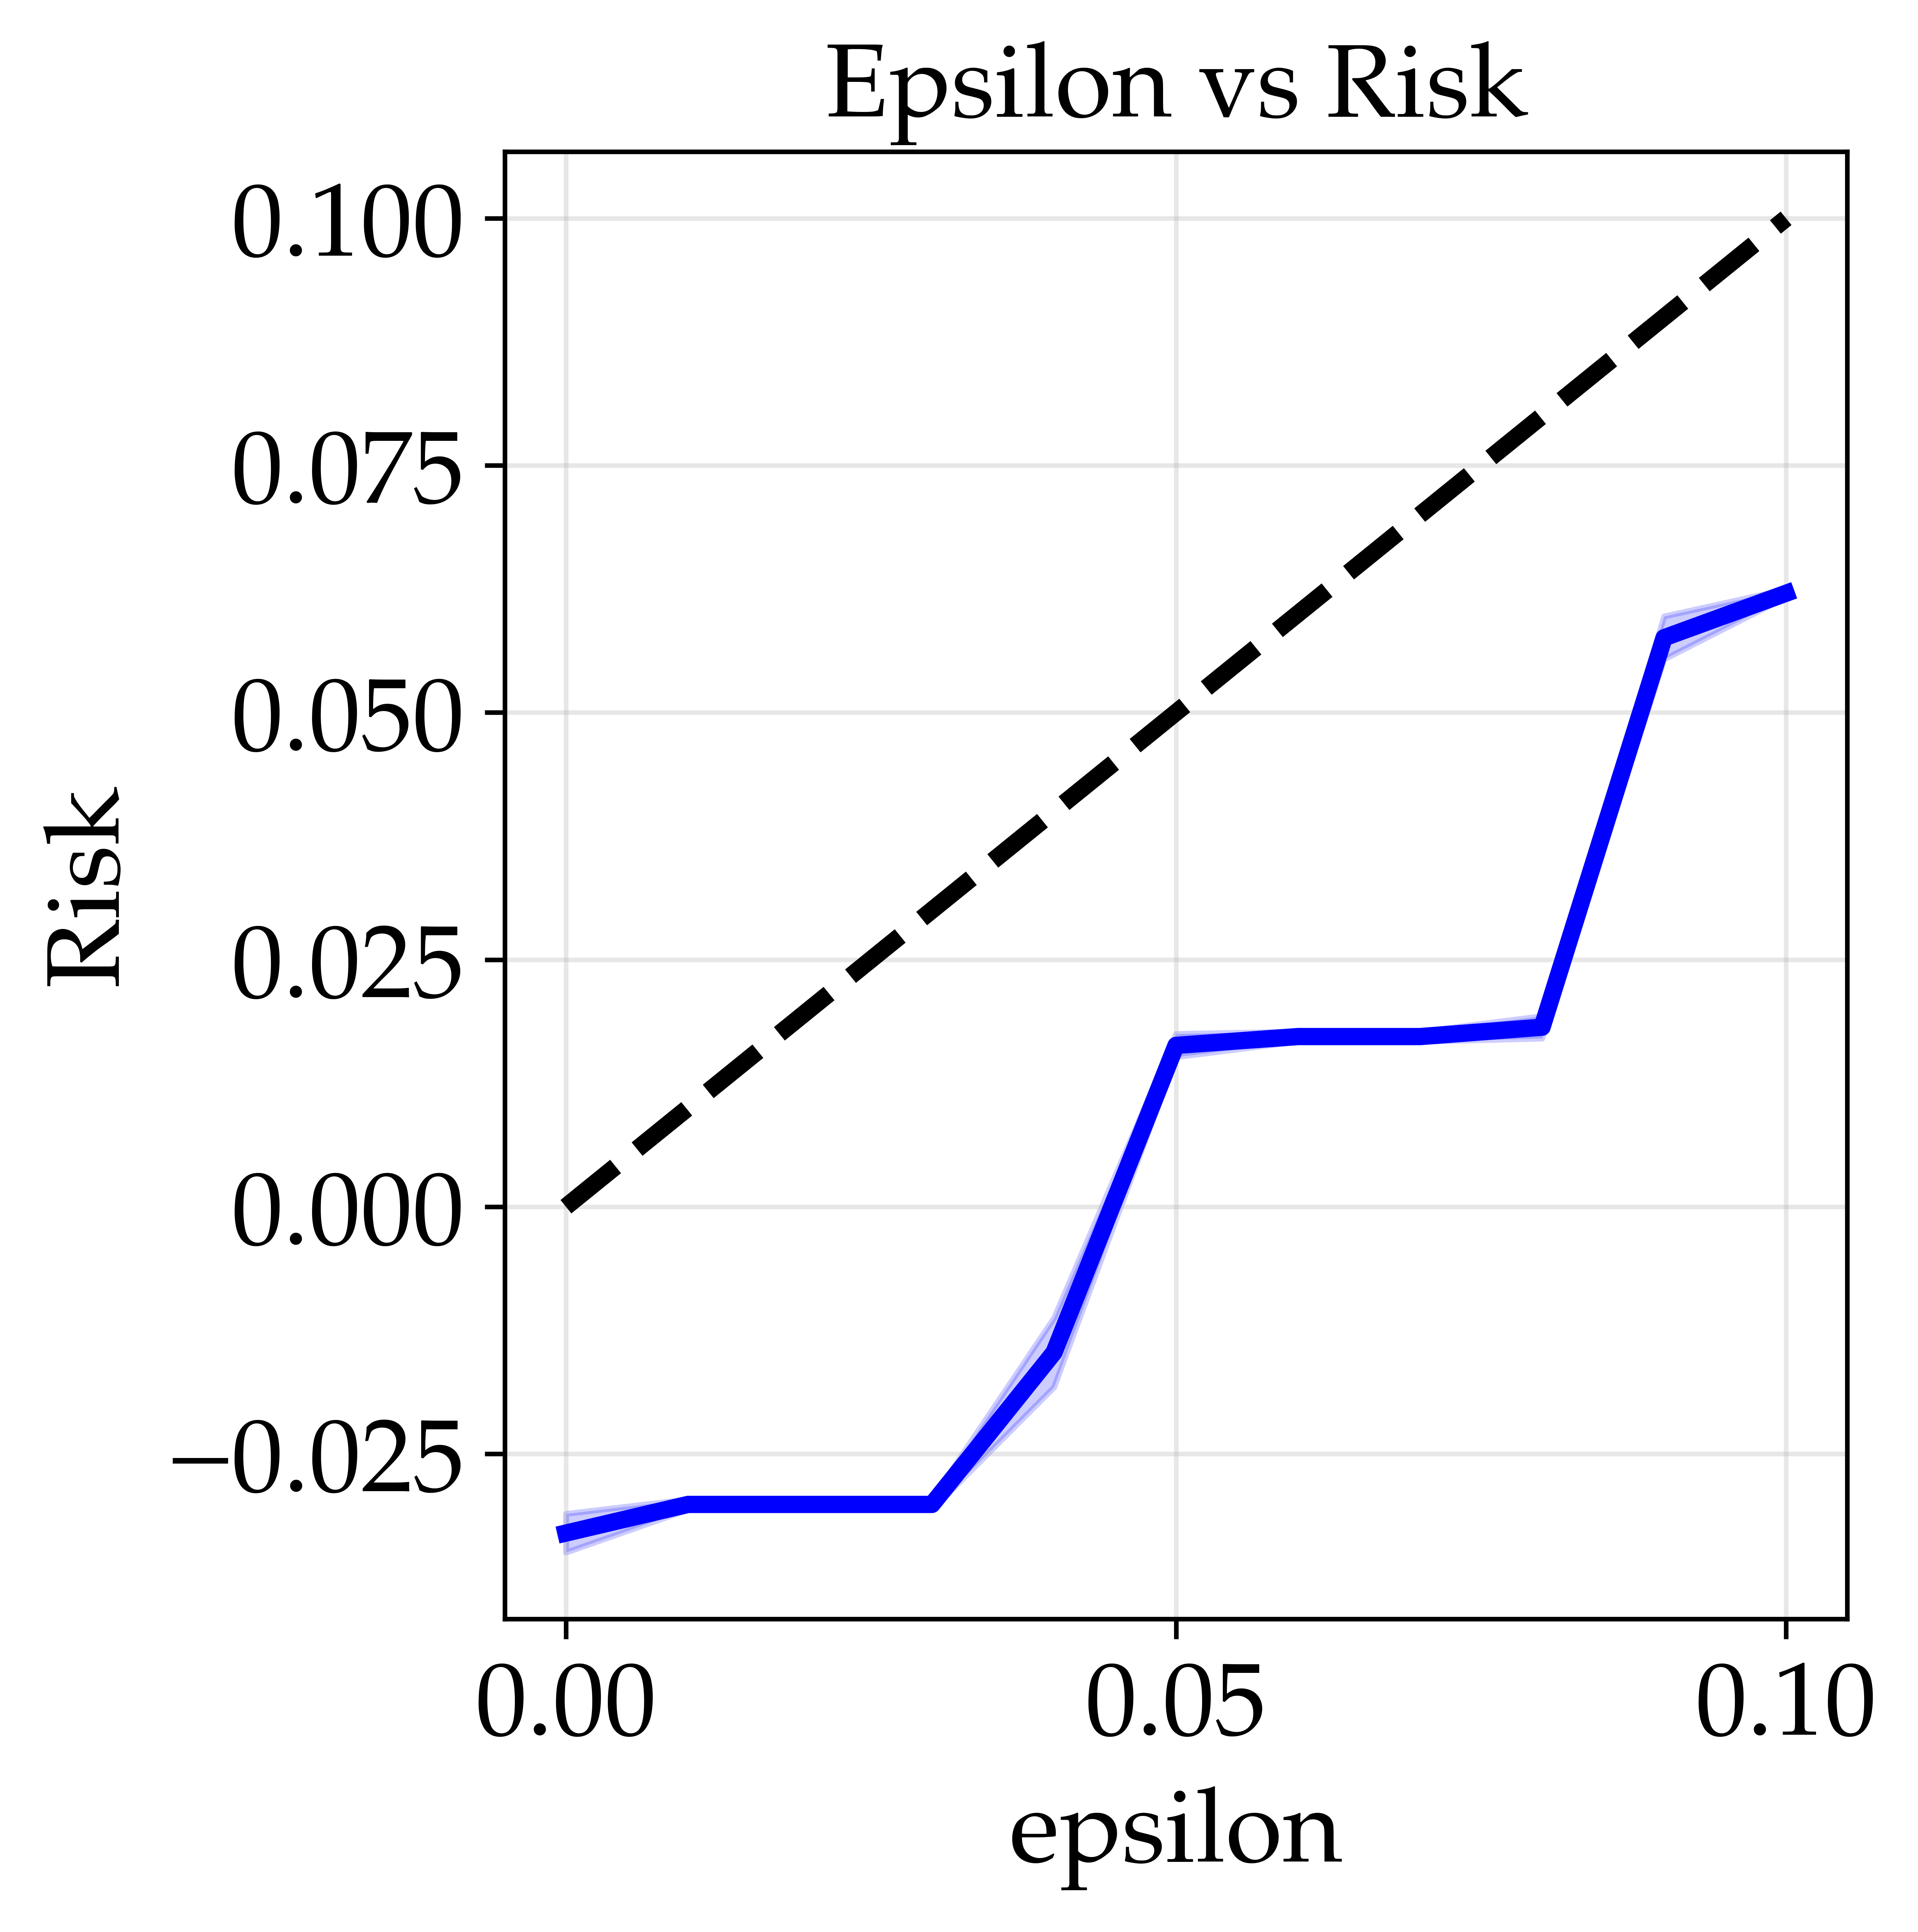

In [21]:
# Scaling risk-control, no clipping
# Risk control plots - with only risk control on combined data
fig, ax = plt.subplots(1,1,figsize=(5,5))
# plot epsilon vs risk
plot_risk_control(ax, eps_grid, losses, scaled_test_risk, 'scaling', 'b', 'solid')

plt.title('Epsilon vs Risk')
plt.tight_layout()

# Save out the image
path = plot_directory + mixed_filename + '/'
if not os.path.exists(path):
    os.makedirs(path)
plt.savefig(path + 'epsilon_vs_risk.pdf')
plt.savefig(path + 'epsilon_vs_risk.png')

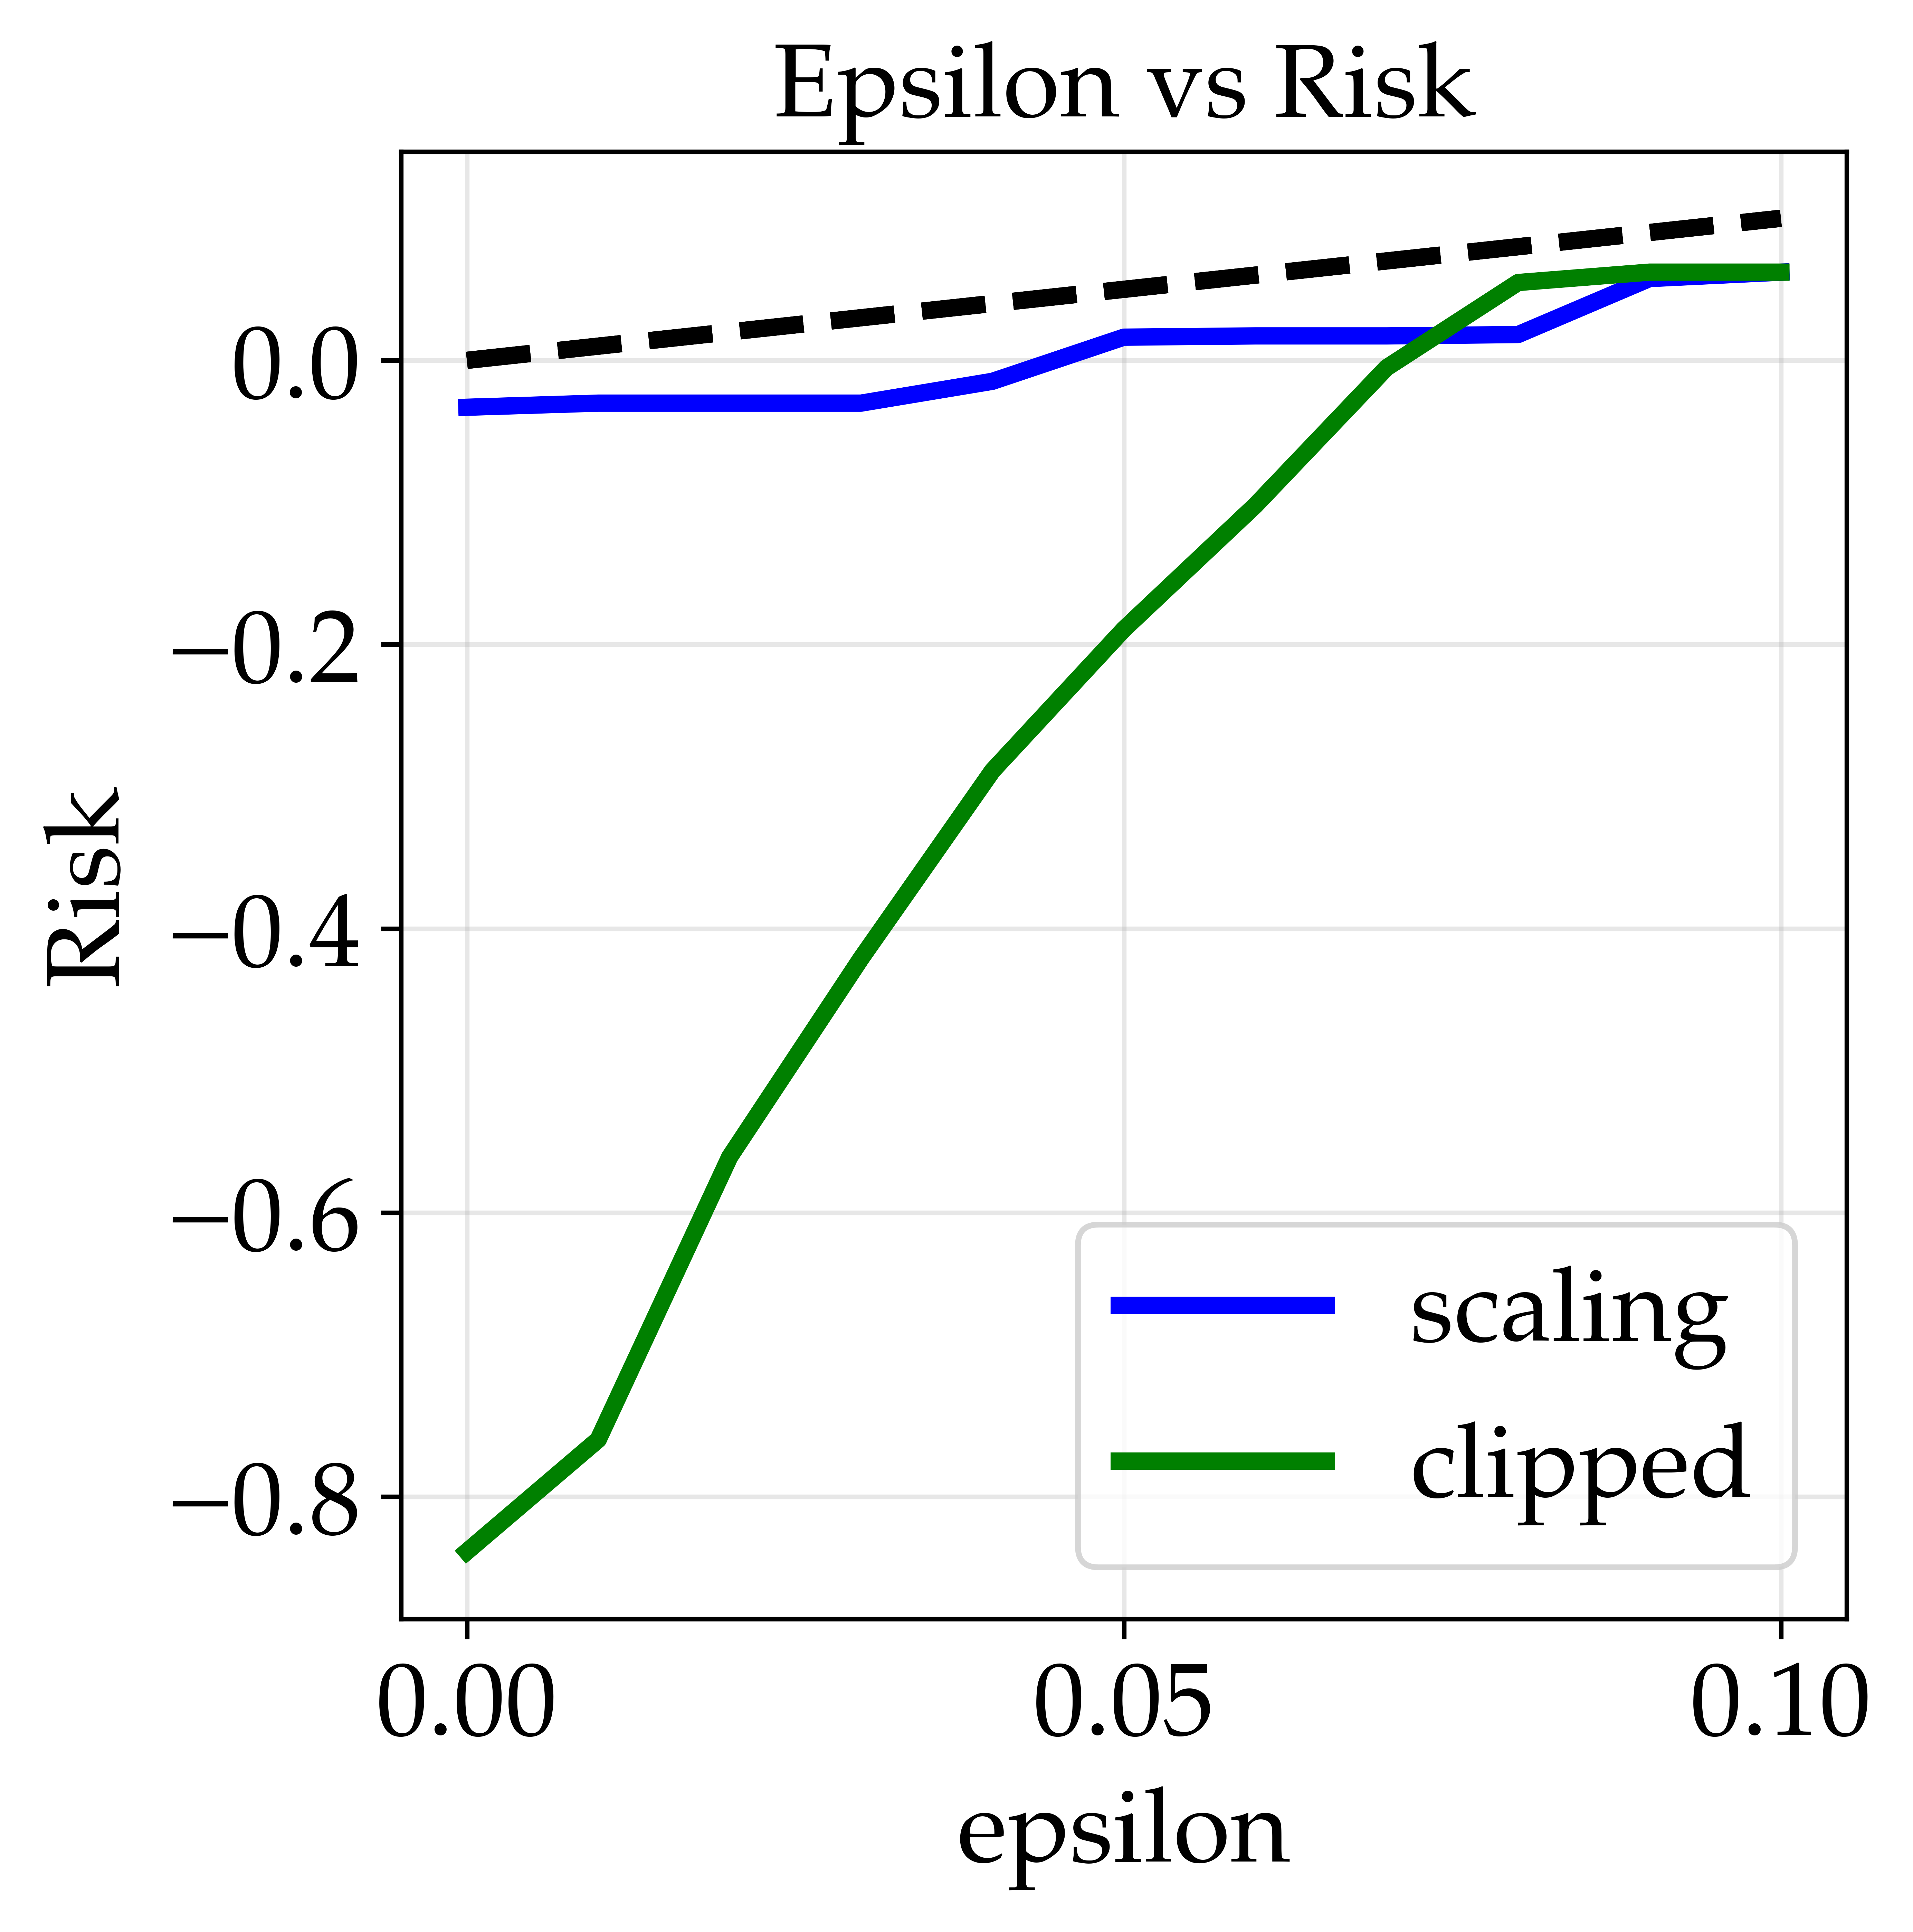

In [22]:
# Comparison: Scaling vs Clipping
# Risk control plots - with only risk control on combined data
fig, ax = plt.subplots(1,1,figsize=(5,5))
# plot epsilon vs risk
plot_risk_control(ax, eps_grid, losses, scaled_test_risk, 'scaling', 'b', 'solid')
#plot_risk_control(ax, eps_grid, losses, scaled_test_risk_no_default, 'scaling (no default)', 'b', 'dotted')
plot_risk_control(ax, eps_grid, losses, clipped_test_risk, 'clipped', 'g', 'solid')

ax.legend()
plt.title('Epsilon vs Risk')
plt.tight_layout()

# Save out the image
path = plot_directory + mixed_filename + '/'
if not os.path.exists(path):
    os.makedirs(path)
plt.savefig(path + 'epsilon_vs_risk_comparison.pdf')
plt.savefig(path + 'epsilon_vs_risk_comparison.png')

## Efficiency Gains - Comparison (Clipping vs Our Approach)
Paper: fig 16

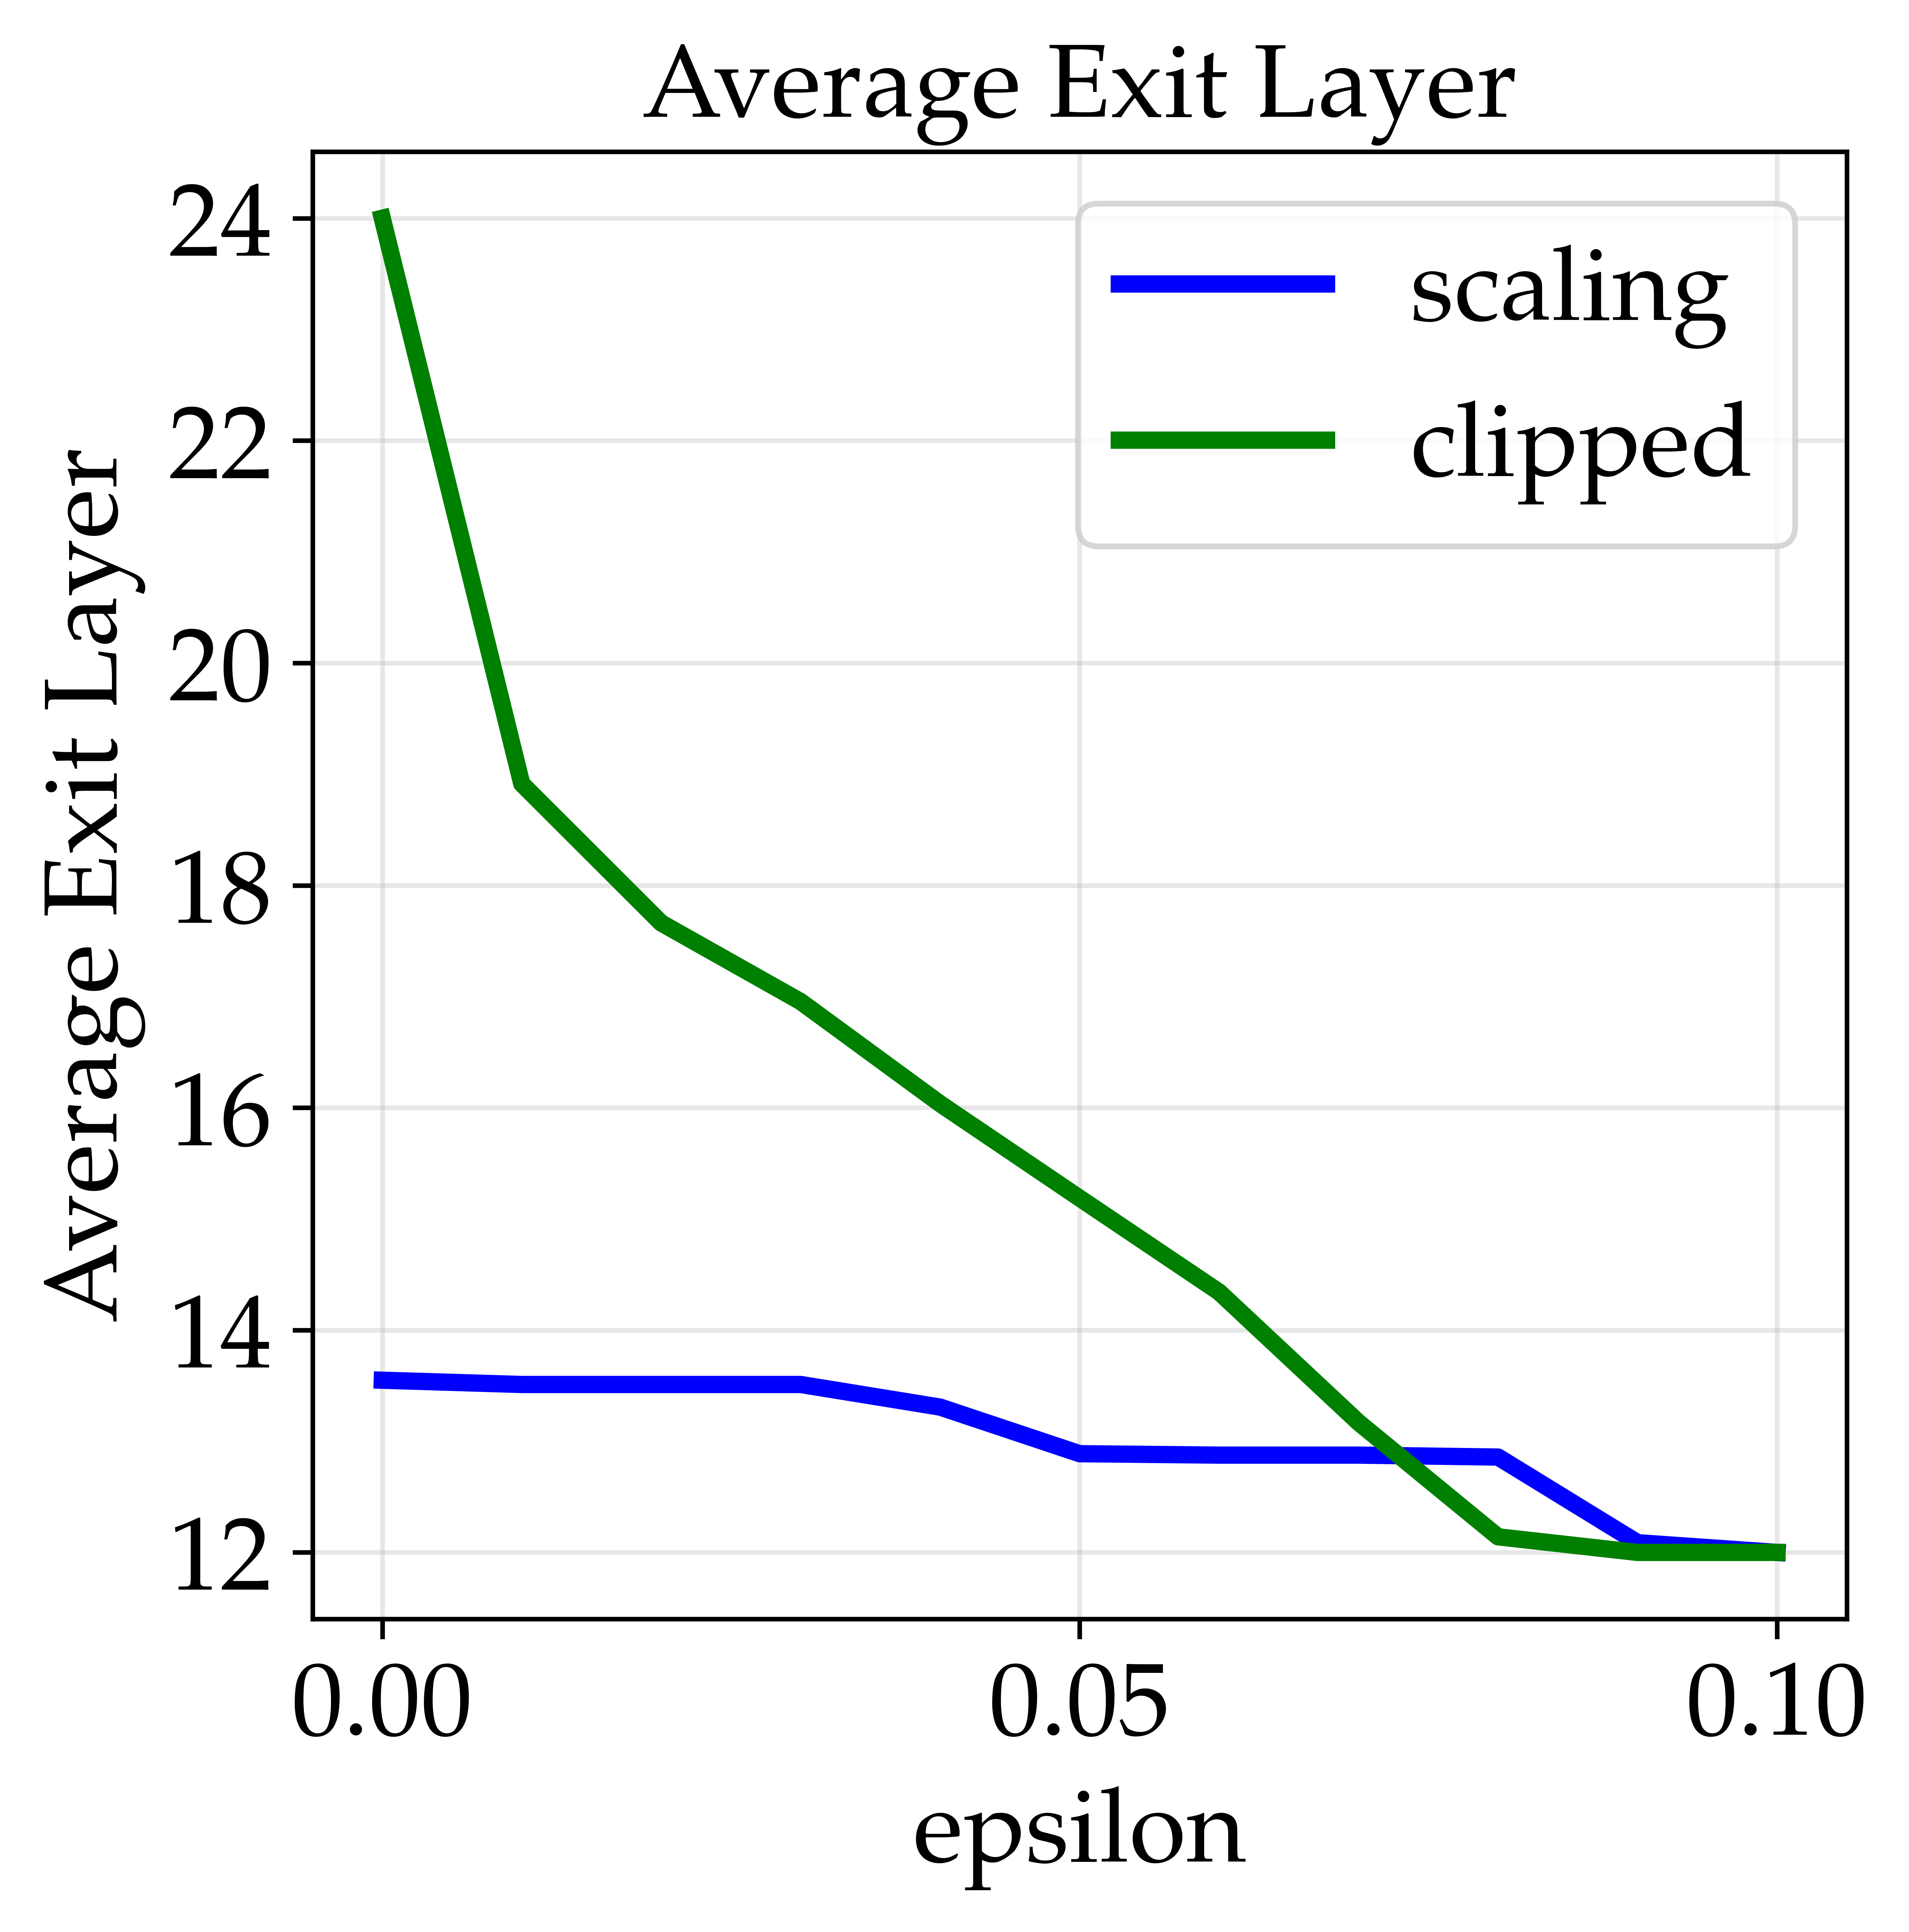

In [24]:
# Plot JUST efficiency gains
fig, ax = plt.subplots(1,1,figsize=(5,5))
# Scaling
plot_efficiency_gains(ax, eps_grid, scaled_eff_gains, 'scaling', 'b', 'solid', n_early_exit)
#plot_efficiency_gains(ax, eps_grid, scaled_eff_gains_no_default, 'scaling (no default)', 'b', 'dotted', n_early_exit)
# max-0
plot_efficiency_gains(ax, eps_grid, clipped_eff_gains, 'clipped', 'g', 'solid', n_early_exit)

ax.legend()
plt.title("Average Exit Layer")
plt.tight_layout()
# Save out the image
path = plot_directory + mixed_filename + '/'
if not os.path.exists(path):
    os.makedirs(path)
plt.savefig(path + 'efficiency_gains_comparison.pdf')
plt.savefig(path + 'efficiency_gains_comparison.png')

In [25]:
# Get a numeric avg efficiency gain
print(scaled_eff_gains.shape)
print(clipped_eff_gains.shape)
diff = clipped_eff_gains - scaled_eff_gains
biggest_diff = diff.mean(axis=0).max()
print("Max percent gain:", round(biggest_diff/12*100,2), "%")

(50, 11)
(50, 11)
Max percent gain: 87.09 %


# Risk vs Lambda

(101, 5928)


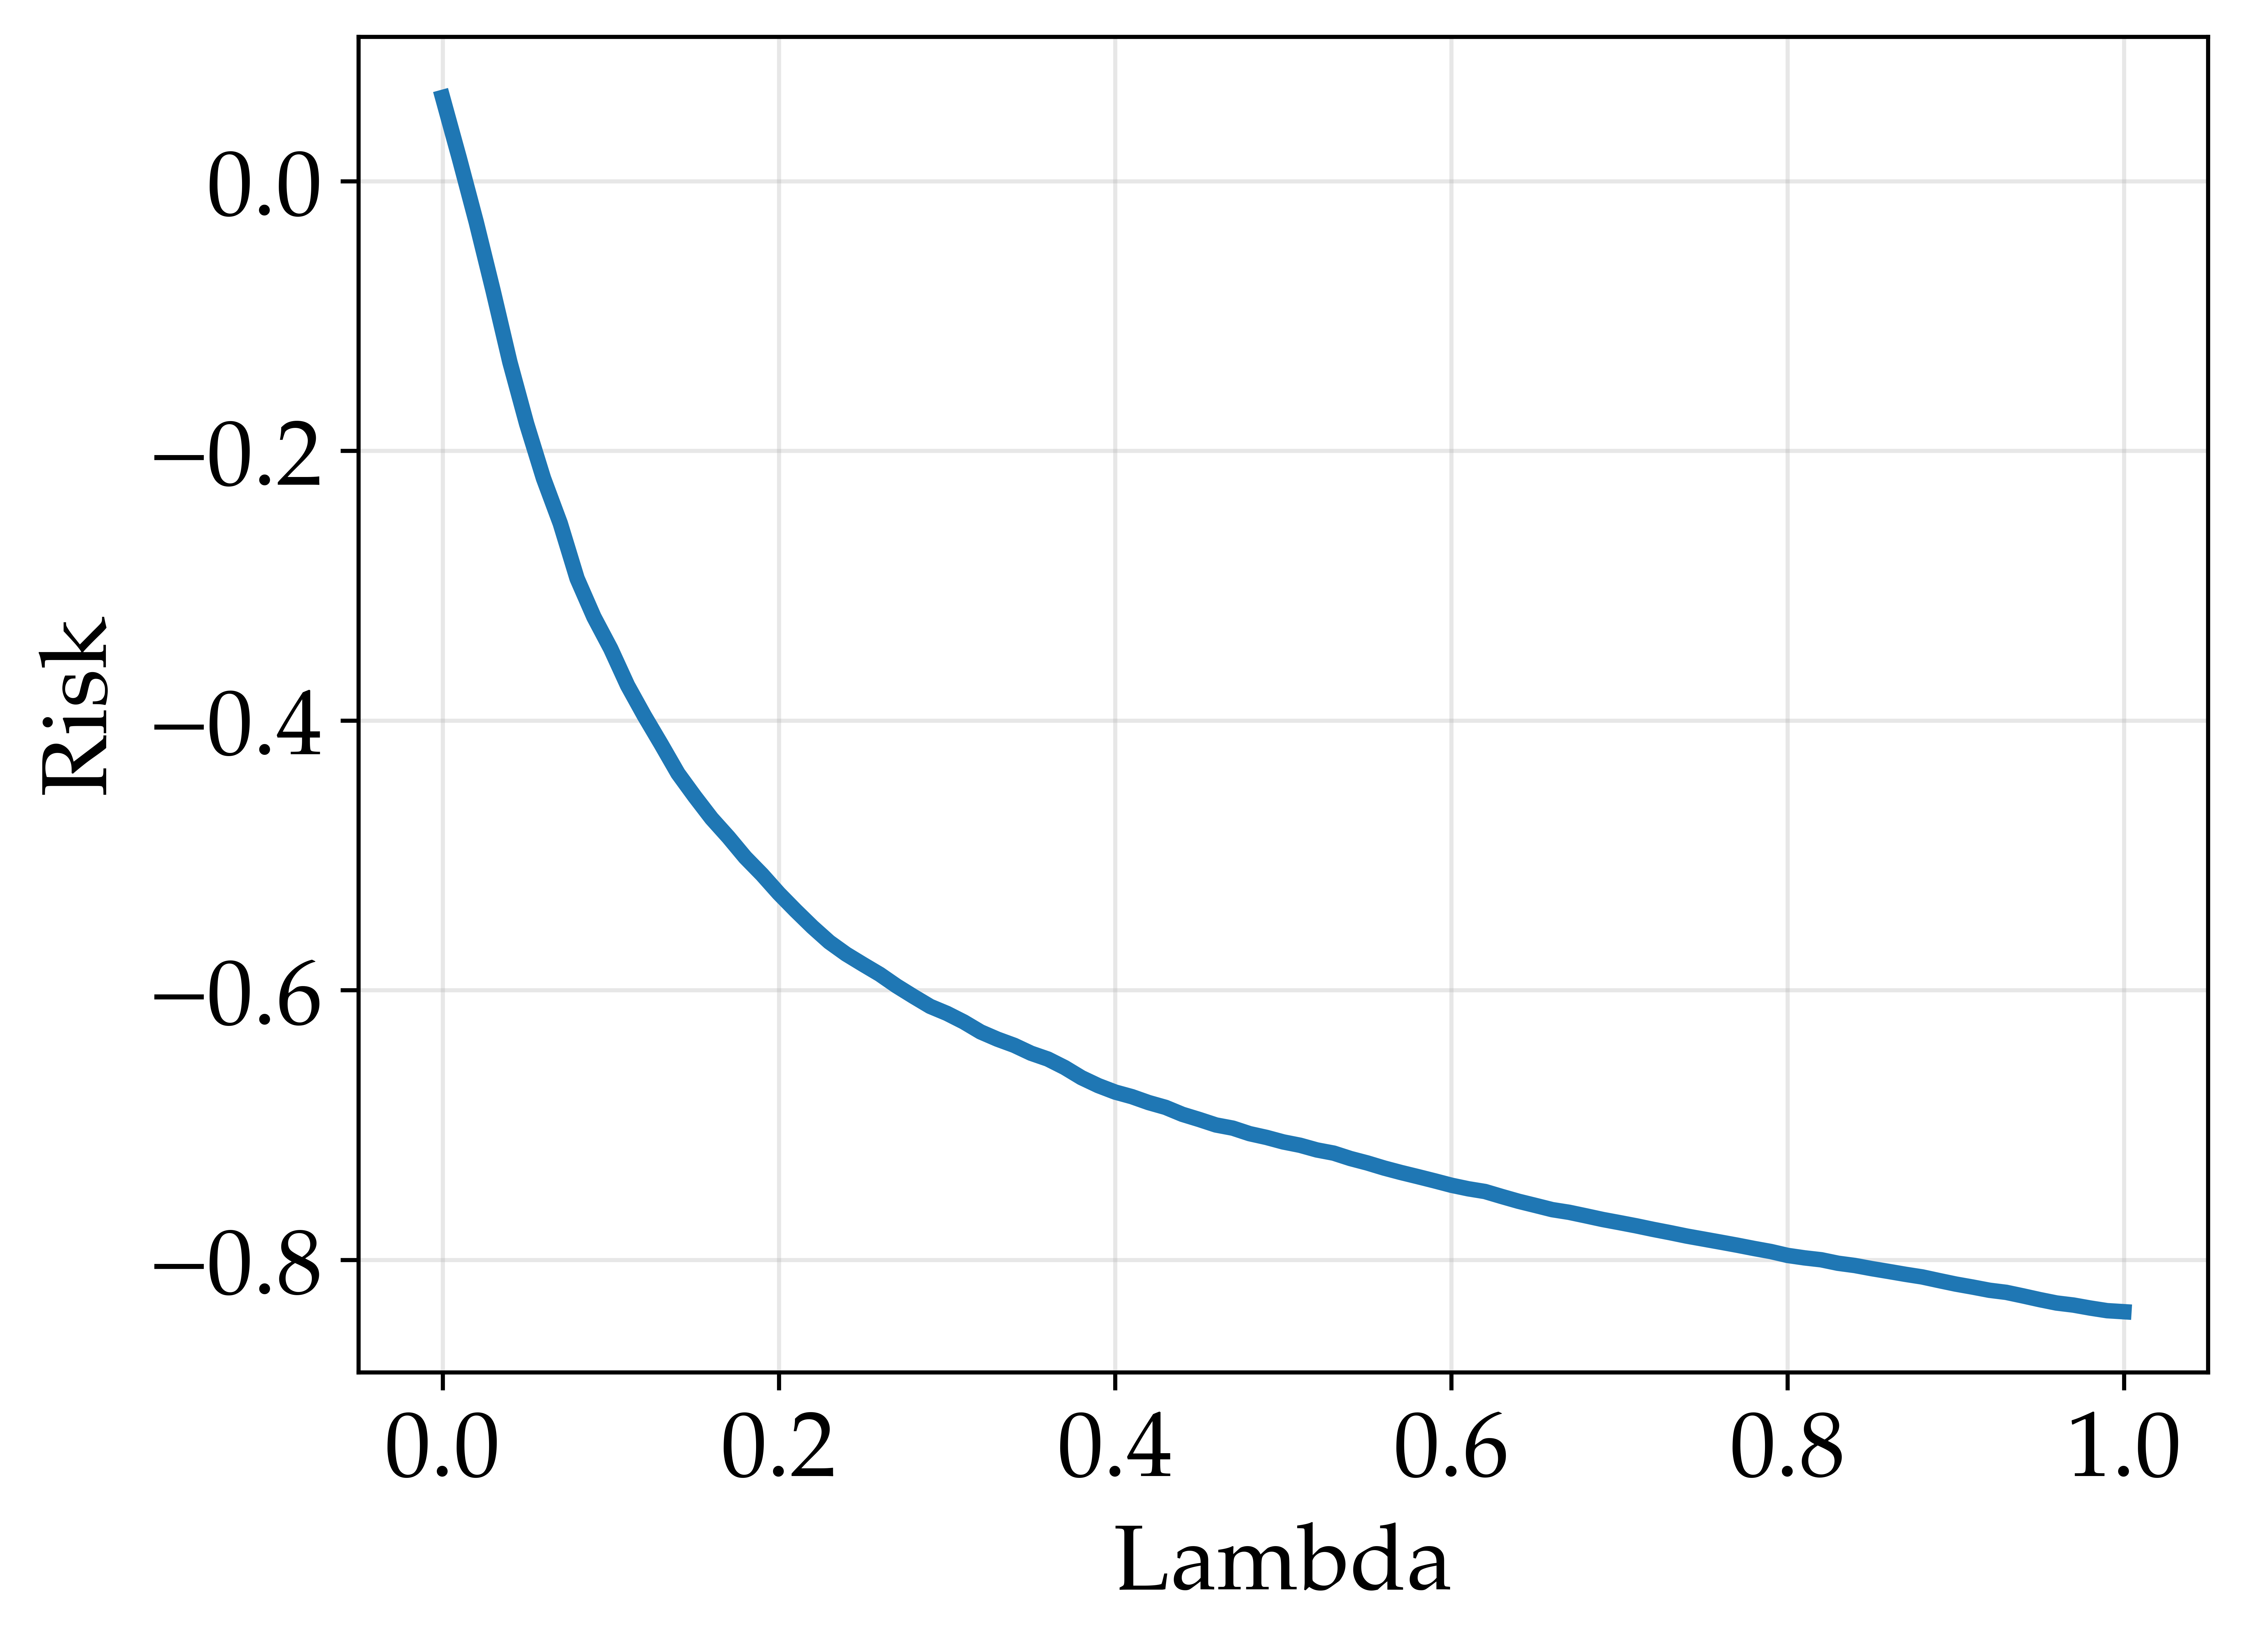

In [27]:
print(losses.shape)
plt.plot(lambdas, losses.mean(axis=1))
plt.xlabel('Lambda')
plt.ylabel('Risk')
plt.savefig(plot_directory + 'lambda_vs_risk.pdf')

# Highlighted Lambda vs Accuracy

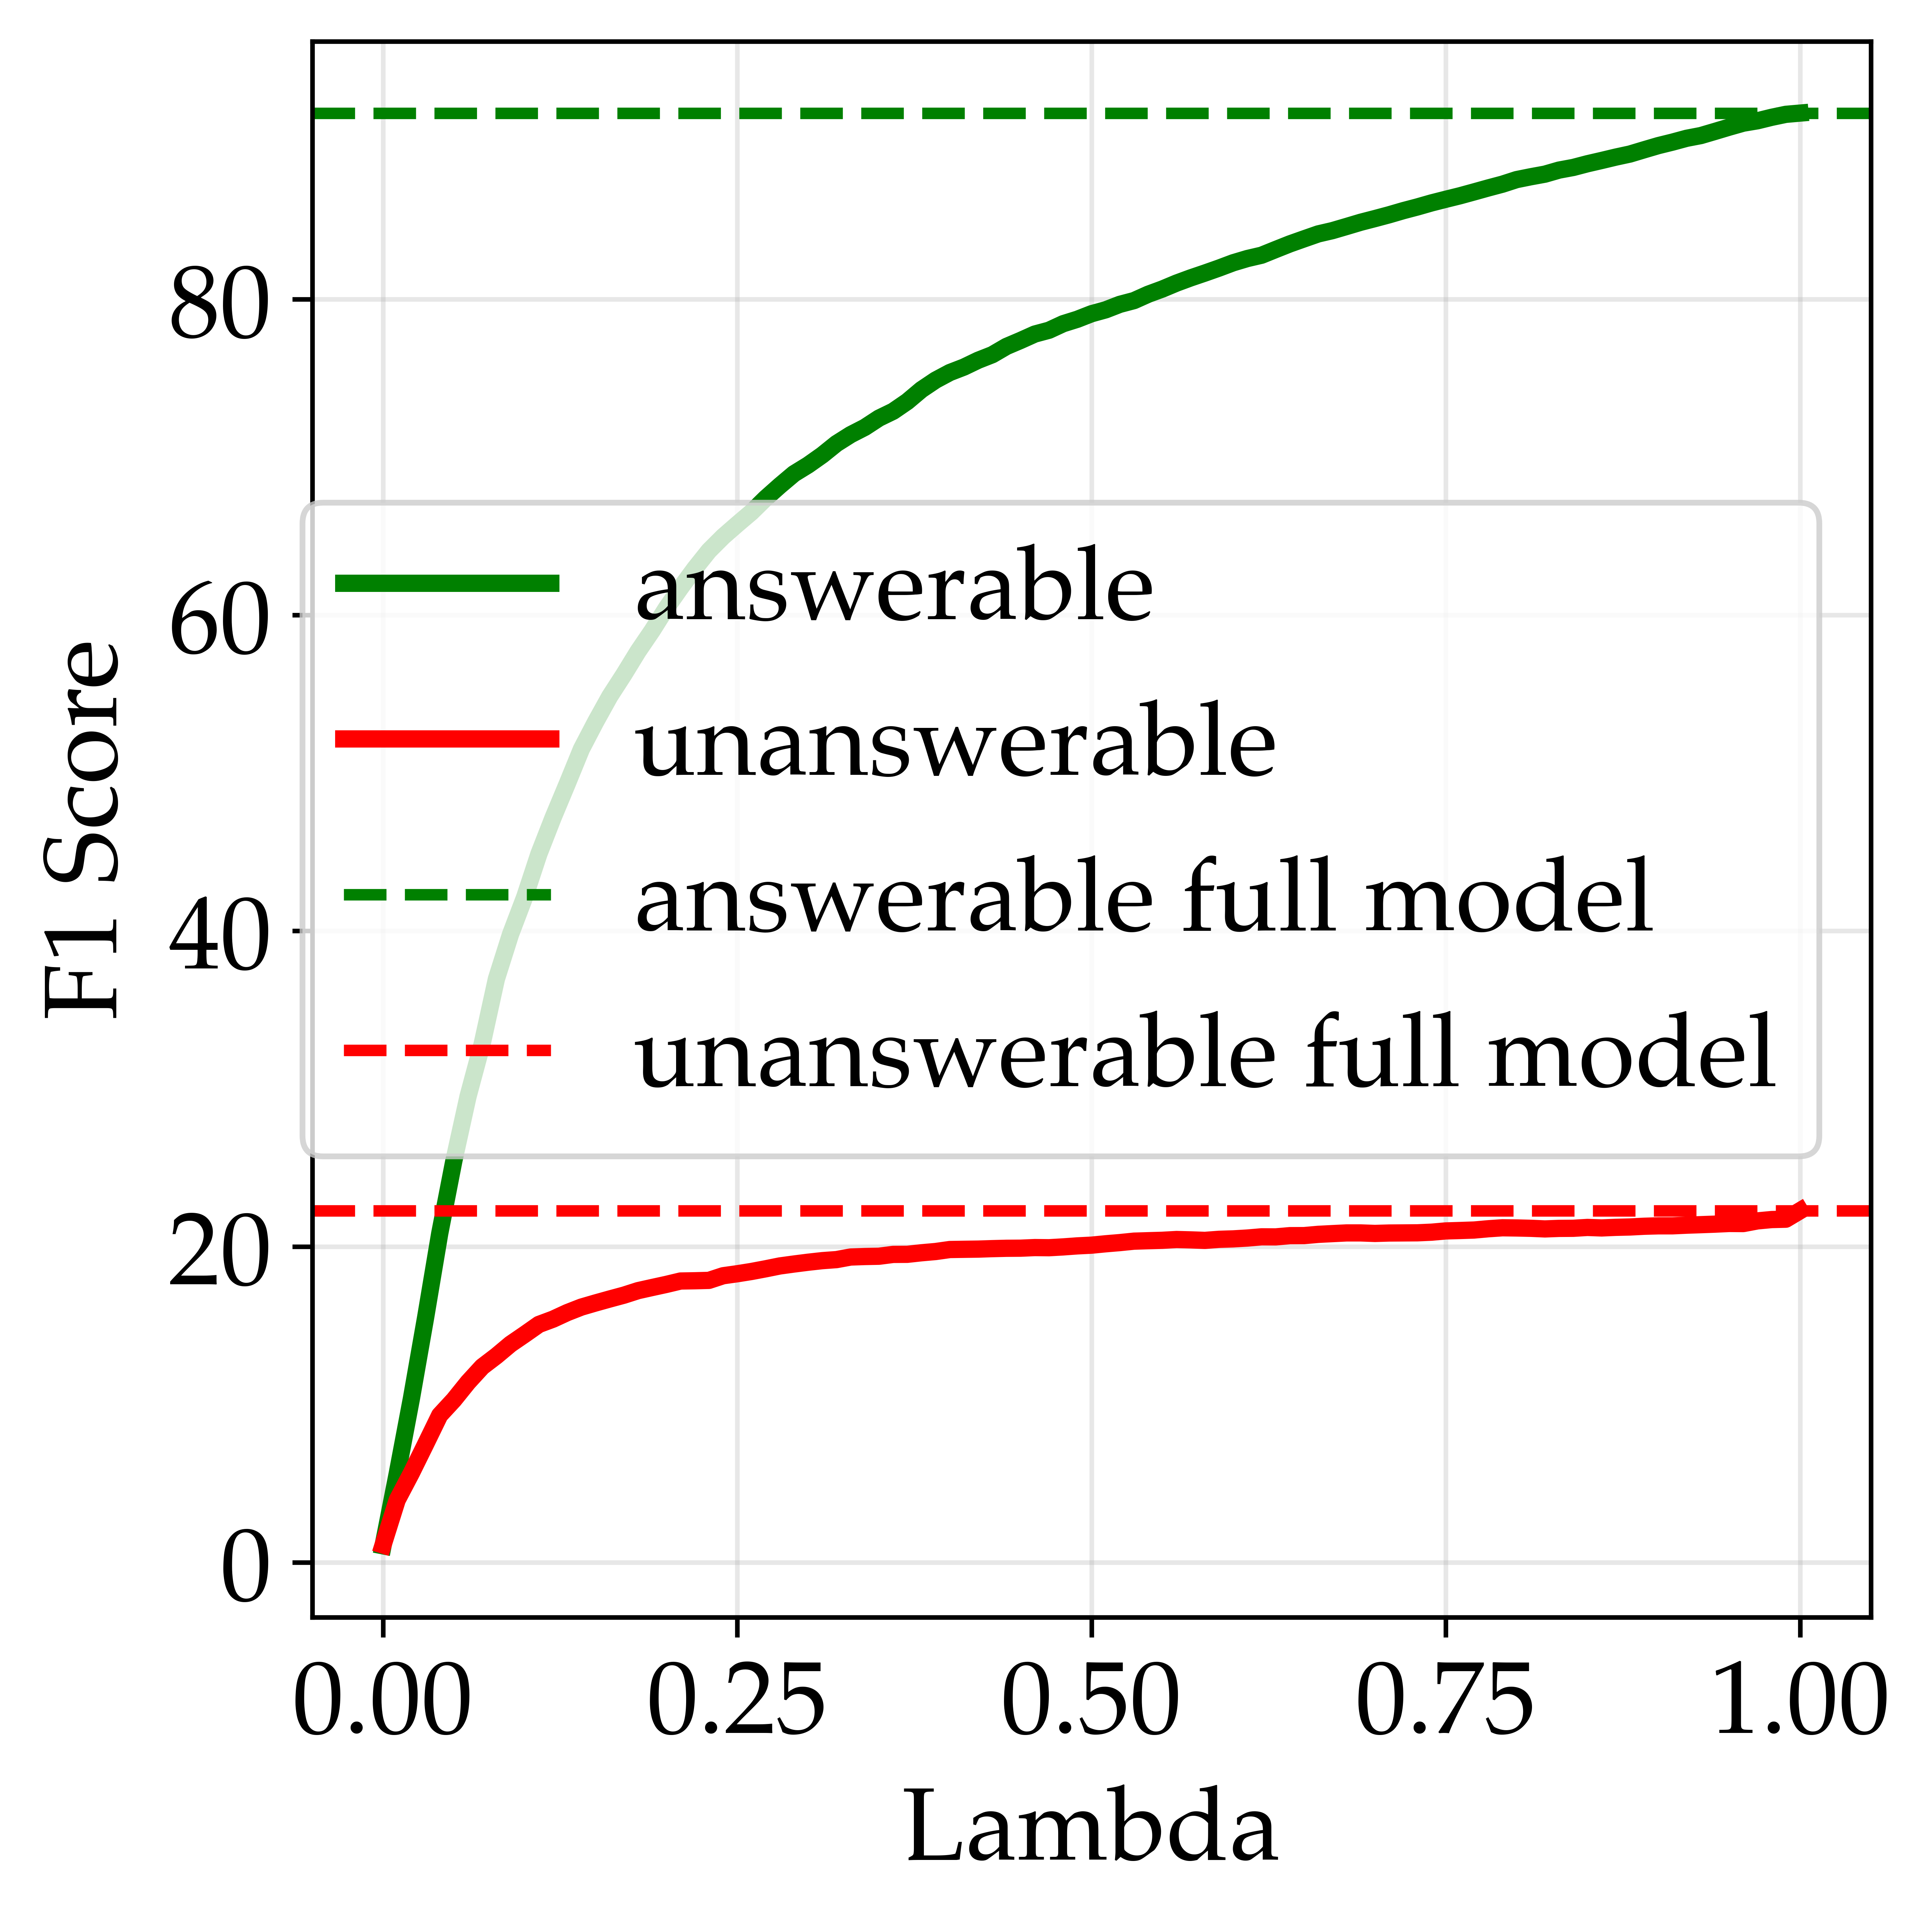

In [29]:
# Plot lambda vs relative accuracy
fig, ax = plt.subplots(1,1,figsize=(5,5))

# Re-load losses; we don't want relative losses here
a_losses = np.load(precomputed_path + "a_losses.npy")
u_losses = np.load(precomputed_path + "u_losses.npy")

# Define colors
a_color, u_color = 'g', 'r'

# Plot lambda vs answerable accuracy
a_f1, a_err = (1-a_losses.mean(axis=1))*100, a_losses.std(axis=1)/np.sqrt(a_losses.shape[1])
a_f1, a_err = a_f1[::-1], a_err[::-1]
ax.plot(lambdas, a_f1, label='answerable', color=a_color)
ax.fill_between(lambdas, a_f1-a_err, a_f1+a_err, color=a_color, alpha=0.3)

# Plot lambda vs incorrect accuracy
u_f1, u_err = (1-u_losses.mean(axis=1))*100, u_losses.std(axis=1)/np.sqrt(u_losses.shape[1])
u_f1, u_err = u_f1[::-1], u_err[::-1]
ax.plot(lambdas, u_f1, label='unanswerable', color=u_color)
ax.fill_between(lambdas, u_f1-u_err, u_f1+u_err, color=u_color, alpha=0.3)

# Plot full-model performance as horizontal lines
avg_a_f1 = a_f1[0]
avg_u_f1 = u_f1[0]
# Plot the full-model F1 score
ax.axhline(y=avg_a_f1, color=a_color, linestyle='--', linewidth=2, label='answerable full model')
ax.axhline(y=avg_u_f1, color=u_color, linestyle='--', linewidth=2, label='unanswerable full model')

valid_lams = []
for lam_idx in range(len(lambdas)):
    idx = len(lambdas)-lam_idx-1
    if (avg_a_f1 - a_f1[idx]) - a_err[idx] < 0.05 and u_f1[idx] - u_err[idx] >= avg_u_f1:
        valid_lams.append(len(lambdas)-lam_idx-1)

intervals_idx = [(g[0][1], g[-1][1]) for _, group in groupby(enumerate(valid_lams), lambda x: x[1] - x[0]) for g in [list(group)]]
for start,end in intervals_idx:
    end = end+1 if start == end and end < len(lambdas)-1 else end
    plt.axvspan(lambdas[start], lambdas[end], facecolor='yellow', alpha=0.3)

ax.set_xlabel('Lambda')
ax.set_ylabel('F1 Score')
ax.legend()
plt.tight_layout()

# Save out the image
path = plot_directory
if not os.path.exists(path):
    os.makedirs(path)
plt.savefig(path + 'lambda_vs_f1.pdf')
plt.savefig(path + 'lambda_vs_f1.png')